In [8]:
import pandas as pd
df = pd.read_csv('titanic.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
# Suponiendo que tu dataframe se llama 'df'
plt.figure(figsize=(10, 6))
# El mapa de calor buscará los valores nulos (True) y los pintará
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos (Antes de limpiar)')
plt.show()

NameError: name 'plt' is not defined

In [3]:
# 1. Rellenar los nulos de 'Age' con la mediana (el valor central)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Rellenar los nulos de 'Embarked' con la moda (el puerto más frecuente)
moda_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(moda_embarked)

# 3. Eliminar la columna 'Cabin' por completo porque falta demasiada información
df = df.drop(columns=['Cabin'])

# 4. Comprobar que ya no quedan valores nulos
print("--- DATOS FALTANTES DESPUÉS DE LA LIMPIEZA ---")
print(df.isnull().sum())

--- DATOS FALTANTES DESPUÉS DE LA LIMPIEZA ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [4]:
# 1. Convertir el sexo a números (0 para hombres, 1 para mujeres)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. Convertir el puerto de embarque a columnas numéricas (One-Hot Encoding)
# Esto creará columnas como 'Embarked_Q' y 'Embarked_S' con valores de 0 o 1 (True/False)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# 3. Eliminar columnas de texto que son muy complejas para un modelo básico
# El nombre y el número de ticket no nos sirven como están ahora
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# Veamos cómo quedó nuestro nuevo dataset puramente numérico
print(df.head())


   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


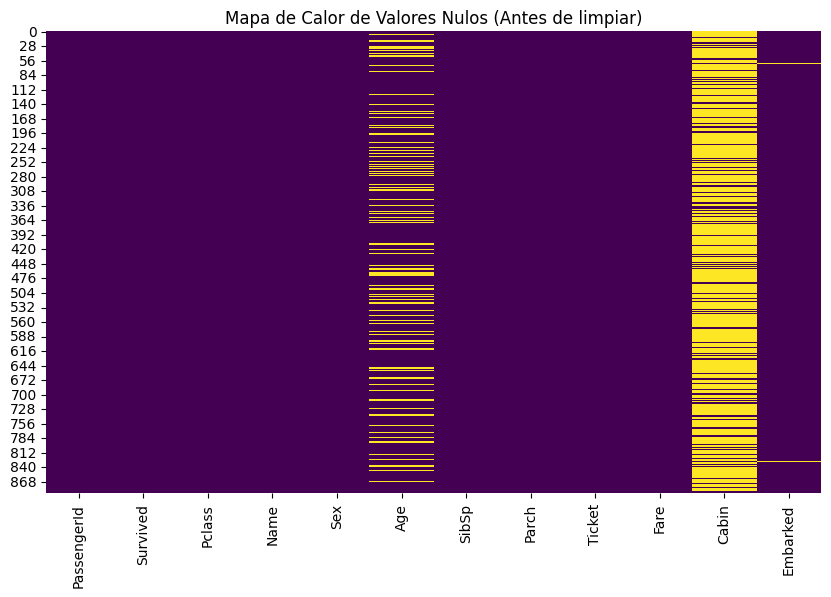

In [11]:
# 1. Importar todas las herramientas necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Cargar los datos originales (los que tienen datos nulos)
df = pd.read_csv('titanic.csv')

# 3. Dibujar el mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Antes de limpiar)')
plt.show()


In [12]:
# 1. Rellenamos Edad con la mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Rellenamos Embarque con la moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Borramos la columna de Cabina
df = df.drop(columns=['Cabin'])

print("Limpieza completada con éxito.")

Limpieza completada con éxito.


In [13]:
df.drop('Cabin', axis = 1, inplace = True)


KeyError: "['Cabin'] not found in axis"

In [14]:
# 1. Volvemos a cargar los datos originales limpios para evitar confusiones
df = pd.read_csv('titanic.csv')

# 2. Eliminamos la columna Cabin (Instrucción de tu curso)
df.drop('Cabin', axis=1, inplace=True)

# 3. Calculamos la media de Age y rellenamos los nulos (Instrucción de tu curso)
mean_age = df['Age'].mean()
df['Age'].fillna(mean_age, inplace=True)

print("Limpieza oficial del curso completada.")

Limpieza oficial del curso completada.


C:\Users\Diego\AppData\Local\Temp\ipykernel_1288\133482739.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(mean_age, inplace=True)


In [15]:
import os

# 1. Verificar si hay filas duplicadas
print("Duplicados encontrados:", df.duplicated().sum())

# 2. Eliminar columnas que no le sirven al modelo (nombres, números de ticket y IDs)
# Podemos ponerlas todas juntas en una lista para ahorrar líneas de código
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# 3. Ver las dimensiones finales de nuestra tabla
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")

# 4. Crear la carpeta 'data' si no existe y guardar nuestro progreso
if not os.path.exists('./data'):
    os.makedirs('./data')

df.to_csv('./data/titanic_clean.csv', index=False)
print("¡Archivo 'titanic_clean.csv' guardado con éxito! Listo para la Fase 2.")

Duplicados encontrados: 0
Después de limpiar df: 891 filas y 8 columnas.
¡Archivo 'titanic_clean.csv' guardado con éxito! Listo para la Fase 2.
